<a href="https://colab.research.google.com/github/Dcush05/LearningCuda/blob/main/Learning_Cuda_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!nvcc

nvcc fatal   : No input files specified; use option --help for more information


In [15]:
!nvcc --version
!pip install nvcc4jupyter
%load_ext nvcc4jupyter
%reload_ext nvcc4jupyter

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpnwc_chdi".


In [20]:
# Detect selected GPU and its NVIDA architecture:
import subprocess
gpu_info = subprocess.getoutput("nvidia-smi --query-gpu=name,compute_cap --format=csv,noheader,nounits")
if "not found" in gpu_info.lower(): raise RuntimeError("Error: No GPU found. Please select a GPU runtime environment.")
gpu_name, compute_cap = map(str.strip, gpu_info.split(','))
gpu_arch = f"sm_{compute_cap.replace('.', '')}"

print(f"{'GPU Name':<15}: {gpu_name}")
print(f"{'Architecture':<15}: {gpu_arch}")

GPU Name       : Tesla T4
Architecture   : sm_75


In [27]:
%%cuda -c "--gpu-architecture sm_75"
#include <stdio.h>


// global - function that can be accessed on both gpu and cpu
// device - function that can only be accessed on gpu
// host - function that can only be accessed on the cpu
//These are execution space identifiers

__global__ void whoami(void)
{

  //testing getting the block id
  //There are different ways to get id's based on the dimensions of the block
  //int global_block_id = blockIdx.x + blockIdx.y * gridDim.x + blockIdx.z * gridDim.x * gridDim.y;
  int global_block_id = blockIdx.x;
  int global_thread_id = threadIdx.x + blockIdx.x * blockDim.x;



  printf("Block id: %d, Thread id: %d\n", global_block_id, global_thread_id);

}


int main(void)
{
    printf("Hello world\n");
    int blocks_per_grid = 2;
    int threads_per_block = 4;

    whoami<<<blocks_per_grid, threads_per_block>>>();

    cudaDeviceSynchronize();
}





Hello world
Block id: 0, Thread id: 0
Block id: 0, Thread id: 1
Block id: 0, Thread id: 2
Block id: 0, Thread id: 3
Block id: 1, Thread id: 4
Block id: 1, Thread id: 5
Block id: 1, Thread id: 6
Block id: 1, Thread id: 7



**Lesson 1**


Host - CPU
Device - GPU

CPU runs functions
GPU runs kernels which are functions that run on the GPU.


A typical CUDA program is made up of 4 chracteristics.

CPU allocating memory

*   CPU allocating memory
*   CPU copies data to GPU

*   CPU launches a kernel on GPU
* The results from the GPU is copied back to CPU to do something useful with it.


Photos on GPU ARCH and the the structure of a GPU vs CPU:


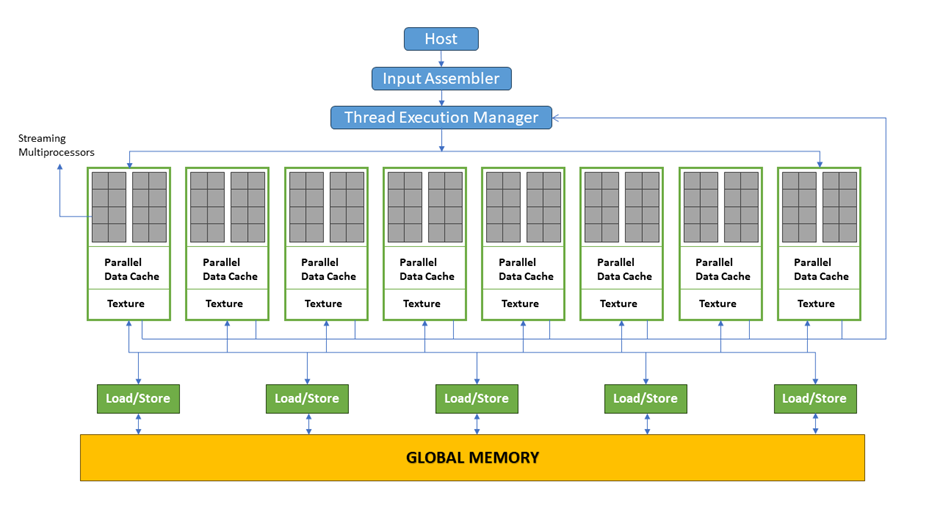

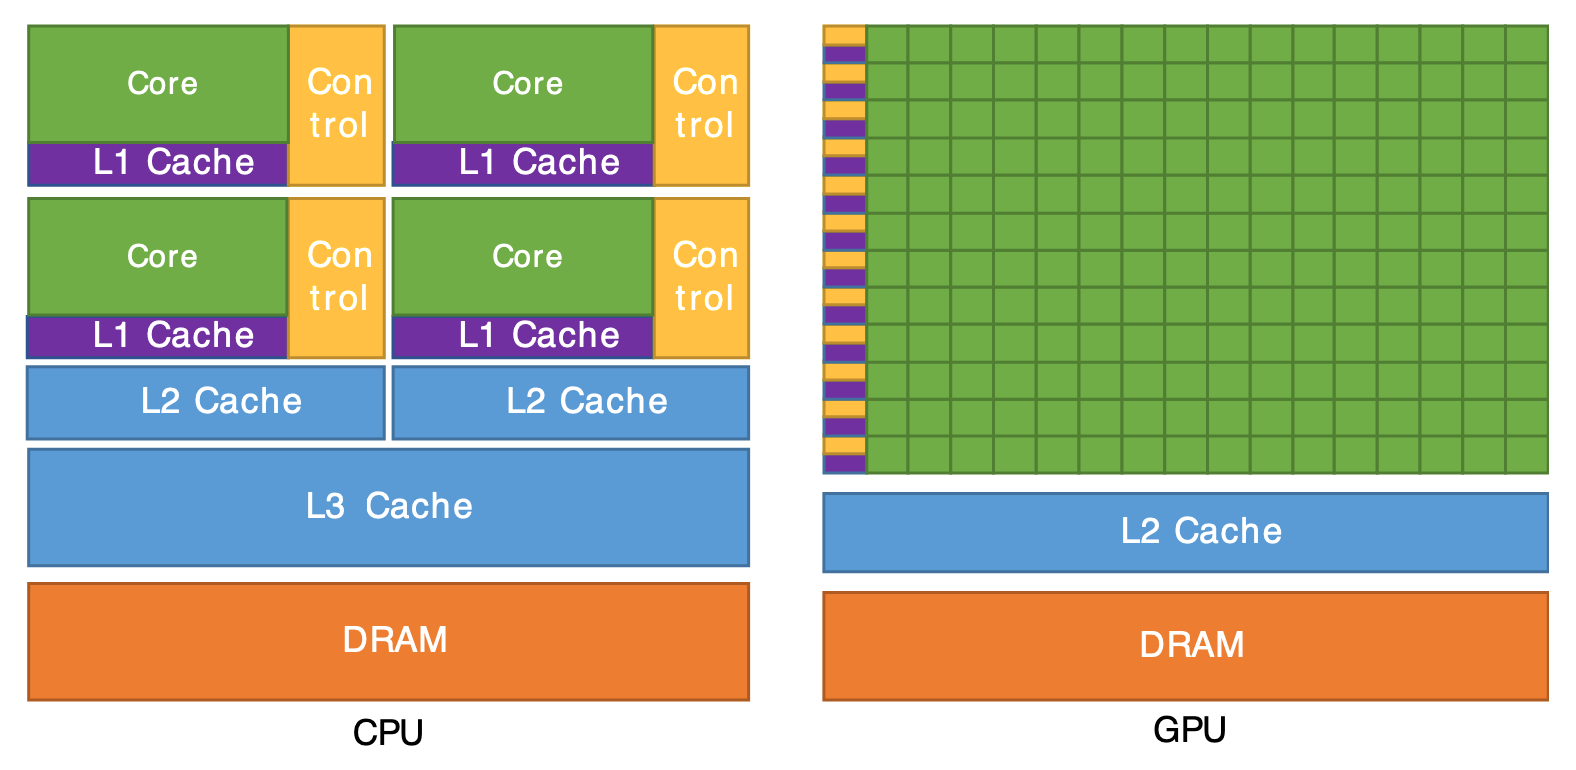



